# 00 — Notebook principal de integración y validación final del proyecto

Este notebook es el punto de entrada final del proyecto de Machine Learning sobre los documentos desclasificados del 23-F.

Su objetivo no es repetir todo el desarrollo técnico de los notebooks específicos, sino **integrar, validar y resumir** los resultados finales del repositorio. El desarrollo completo de cada fase se encuentra en sus notebooks correspondientes:

- `notebooks/01_data_sources_and_dataset.ipynb`: fuentes, inventario y construcción inicial del dataset.
- `notebooks/02_eda_documental_rtve.ipynb`: análisis exploratorio documental.
- `notebooks/03_limpieza_general_corpus.ipynb`: limpieza base del corpus.
- `notebooks/04_caso_uso1_clasificacion_institucional.ipynb`: clasificación institucional.
- `notebooks/05_caso_uso2.ipynb`: clustering temático.
- `notebooks/06_caso_uso3.ipynb`: grafo de entidades.
- `notebooks/07_caso_uso4_asistente_semantico.ipynb`: asistente documental semántico.
- `notebooks/08_caso_uso5_fichas_documentales.ipynb`: generación de fichas documentales.

Este notebook comprueba que la estructura del repositorio es coherente, que los datasets principales existen, que los outputs oficiales de cada caso están disponibles y que no hay rutas absolutas en los notebooks versionados.


## 1. Configuración reproducible y rutas relativas

Primero se define una configuración común para localizar la raíz del repositorio y construir todas las rutas necesarias con `pathlib.Path`.

Esta celda permite ejecutar el notebook tanto desde la raíz del proyecto como desde la carpeta `notebooks/`, sin depender de rutas locales del ordenador de ningún integrante del equipo.


In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
from IPython.display import display, Image

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

def find_project_root(start_path=None):
    """
    Busca la raíz del repositorio subiendo desde el directorio actual hasta encontrar
    las carpetas mínimas esperadas del proyecto.
    """
    current_path = Path.cwd().resolve() if start_path is None else Path(start_path).resolve()
    
    for candidate in [current_path] + list(current_path.parents):
        if (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate
    
    raise FileNotFoundError(
        "No se ha podido localizar la raíz del proyecto. "
        "Ejecuta este notebook desde la raíz del repositorio o desde la carpeta notebooks."
    )

PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
DATA_INTERIM_DIR = DATA_DIR / "interim"
DATA_PROCESSED_DIR = DATA_DIR / "processed"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUT_TABLES_DIR = OUTPUTS_DIR / "tables"
OUTPUT_FIGURES_DIR = OUTPUTS_DIR / "figures"
DOCS_DIR = PROJECT_ROOT / "docs"

print("Raíz del proyecto detectada correctamente.")
print(f"data/: {DATA_DIR.relative_to(PROJECT_ROOT)}")
print(f"notebooks/: {NOTEBOOKS_DIR.relative_to(PROJECT_ROOT)}")
print(f"outputs/: {OUTPUTS_DIR.relative_to(PROJECT_ROOT)}")

Raíz del proyecto detectada correctamente.
data/: data
notebooks/: notebooks
outputs/: outputs


**Lectura del output.**  
La raíz del proyecto se detecta correctamente y las rutas principales se muestran de forma relativa. Esto confirma que el notebook no depende de una ruta local concreta y puede pasar a validar la estructura del repositorio.


## 2. Comprobación de estructura mínima del repositorio

Antes de cargar datos, se comprueba que existen las carpetas que estructuran la entrega: datos, notebooks, outputs y documentación.

Esta validación detecta problemas de empaquetado o de estructura antes de avanzar hacia lecturas de archivos concretos.


In [2]:
required_directories = [
    DATA_DIR,
    DATA_INTERIM_DIR,
    DATA_PROCESSED_DIR,
    NOTEBOOKS_DIR,
    OUTPUTS_DIR,
    OUTPUT_TABLES_DIR,
    OUTPUT_FIGURES_DIR,
    DOCS_DIR,
]

directory_check = pd.DataFrame({
    "path": [str(path.relative_to(PROJECT_ROOT)) for path in required_directories],
    "exists": [path.exists() for path in required_directories],
    "is_dir": [path.is_dir() for path in required_directories],
})

display(directory_check)

missing_dirs = directory_check[~directory_check["exists"] | ~directory_check["is_dir"]]

if not missing_dirs.empty:
    raise FileNotFoundError(
        "Faltan carpetas obligatorias del repositorio:\n"
        + "\n".join(missing_dirs["path"].tolist())
    )

,path,exists,is_dir
0,data,True,True
1,data/interim,True,True
2,data/processed,True,True
3,notebooks,True,True
4,outputs,True,True
5,outputs/tables,True,True
6,outputs/figures,True,True
7,docs,True,True


**Lectura del output.**  
Todas las carpetas necesarias aparecen disponibles. La estructura separa datos, notebooks, outputs y documentación, lo que permite continuar con la comprobación de archivos concretos.


## 3. Comprobación de archivos obligatorios

Se validan los archivos que este notebook necesita para integrar la entrega:

- notebooks `01–08`;
- datasets procesados principales;
- tablas y figuras oficiales generadas por los casos de uso.

Si falta algún archivo, el notebook se detiene con un error explícito. Esto evita errores menos claros en fases posteriores.


In [3]:
required_notebooks = [
    "00_main_pipeline.ipynb",
    "01_data_sources_and_dataset.ipynb",
    "02_eda_documental_rtve.ipynb",
    "03_limpieza_general_corpus.ipynb",
    "04_caso_uso1_clasificacion_institucional.ipynb",
    "05_caso_uso2.ipynb",
    "06_caso_uso3.ipynb",
    "07_caso_uso4_asistente_semantico.ipynb",
    "08_caso_uso5_fichas_documentales.ipynb",
]

required_processed_files = [
    "rtve_corpus_clean_base.csv",
    "rtve_corpus_eda_descriptive.csv",
    "rtve_corpus_chunks.csv",
    "rtve_documentary_summaries_case5.csv",
]

required_output_tables = [
    "caso1_clasificacion_model_metrics.csv",
    "caso1_clasificacion_report_best_model.csv",
    "caso1_clasificacion_confusion_matrix.csv",
    "caso1_clasificacion_top_terms_by_class.csv",
    "caso1_clasificacion_errors_for_review.csv",
    "caso1_clasificacion_unlabeled_predictions.csv",
    "caso2_k_selection_metrics.csv",
    "caso2_cluster_summary.csv",
    "caso2_cluster_terms.csv",
    "caso2_cluster_interpretation.csv",
    "caso2_document_clusters.csv",
    "caso2_cluster_svd_coordinates.csv",
    "caso3_entity_frequency_clean.csv",
    "caso3_graph_edges.csv",
    "caso3_node_metrics.csv",
    "caso3_graph_summary.csv",
    "caso4_busqueda_ejemplos.csv",
    "caso_uso5_resumen_estados.csv",
    "caso_uso5_resumen_metodos.csv",
    "caso_uso5_muestra_revision_manual.csv",
]

required_output_figures = [
    "eda_hist_text_length_words.png",
    "eda_hist_log_text_length_words.png",
    "eda_scatter_pages_words.png",
    "caso1_clasificacion_confusion_matrix.png",
    "caso2_clusters_svd.png",
    "caso3_subgrafo_principal.png",
    "caso4_recall_at_k.png",
    "caso_uso5_metodo_por_longitud.png",
]

required_files = []
required_files += [(NOTEBOOKS_DIR / filename, "notebook") for filename in required_notebooks]
required_files += [(DATA_PROCESSED_DIR / filename, "processed_data") for filename in required_processed_files]
required_files += [(OUTPUT_TABLES_DIR / filename, "output_table") for filename in required_output_tables]
required_files += [(OUTPUT_FIGURES_DIR / filename, "output_figure") for filename in required_output_figures]

files_check = pd.DataFrame({
    "type": [file_type for _, file_type in required_files],
    "path": [str(path.relative_to(PROJECT_ROOT)) for path, _ in required_files],
    "exists": [path.exists() for path, _ in required_files],
    "size_bytes": [path.stat().st_size if path.exists() else 0 for path, _ in required_files],
})

files_summary = (
    files_check
    .groupby("type")
    .agg(
        n_files=("path", "count"),
        n_existing=("exists", "sum"),
        total_size_bytes=("size_bytes", "sum"),
    )
    .reset_index()
)

display(files_summary)
display(files_check)

missing_files = files_check[~files_check["exists"]]

if not missing_files.empty:
    raise FileNotFoundError(
        "Faltan archivos obligatorios para la entrega:\n"
        + "\n".join(missing_files["path"].tolist())
    )

,type,n_files,n_existing,total_size_bytes
0,notebook,9,9,3906121
1,output_figure,8,8,1239928
2,output_table,20,20,395229
3,processed_data,4,4,9796295


,type,path,exists,size_bytes
0,notebook,notebooks/00_main_pipeline.ipynb,True,1720443
1,notebook,notebooks/01_data_sources_and_dataset.ipynb,True,605112
2,notebook,notebooks/02_eda_documental_rtve.ipynb,True,259239
3,notebook,notebooks/03_limpieza_general_corpus.ipynb,True,110916
4,notebook,notebooks/04_caso_uso1_clasificacion_institucional.ipynb,True,219717
5,notebook,notebooks/05_caso_uso2.ipynb,True,210631
6,notebook,notebooks/06_caso_uso3.ipynb,True,558637
7,notebook,notebooks/07_caso_uso4_asistente_semantico.ipynb,True,113641
8,notebook,notebooks/08_caso_uso5_fichas_documentales.ipynb,True,107785
9,processed_data,data/processed/rtve_corpus_clean_base.csv,True,4104995


**Lectura del output.**  
La comprobación muestra que existen los notebooks, datasets procesados y outputs oficiales esperados. Esta validación no interpreta todavía los resultados, pero confirma que el repositorio contiene los elementos mínimos para integrar la entrega.


## 4. Carga y validación del corpus limpio

El archivo `data/processed/rtve_corpus_clean_base.csv` es la base común del proyecto. Contiene los documentos RTVE, texto OCR original, texto limpio, metadatos de trazabilidad y variables institucionales cuando existe correspondencia con La Moncloa.

Esta sección valida que el corpus tiene estructura suficiente para sostener los cinco casos de uso.


In [4]:
corpus_path = DATA_PROCESSED_DIR / "rtve_corpus_clean_base.csv"
df_corpus = pd.read_csv(corpus_path)

required_corpus_columns = [
    "doc_id",
    "title",
    "text_full",
    "text_clean_base",
    "text_clean_length_words",
    "pdf_url",
]

missing_corpus_columns = [
    col for col in required_corpus_columns if col not in df_corpus.columns
]

if missing_corpus_columns:
    raise ValueError(
        "Faltan columnas obligatorias en el corpus limpio: "
        + ", ".join(missing_corpus_columns)
    )

corpus_validation = pd.DataFrame({
    "metric": [
        "n_documents",
        "n_columns",
        "n_unique_doc_id",
        "n_missing_doc_id",
        "n_empty_text_clean_base",
        "n_labeled_moncloa_section",
        "n_unlabeled_moncloa_section",
        "median_text_clean_words",
        "max_text_clean_words",
    ],
    "value": [
        len(df_corpus),
        df_corpus.shape[1],
        df_corpus["doc_id"].nunique(),
        df_corpus["doc_id"].isna().sum(),
        (df_corpus["text_clean_base"].fillna("").str.strip() == "").sum(),
        df_corpus["moncloa_section"].notna().sum() if "moncloa_section" in df_corpus.columns else np.nan,
        df_corpus["moncloa_section"].isna().sum() if "moncloa_section" in df_corpus.columns else np.nan,
        df_corpus["text_clean_length_words"].median(),
        df_corpus["text_clean_length_words"].max(),
    ],
})

display(corpus_validation)

if len(df_corpus) == 0:
    raise ValueError("El corpus limpio no contiene filas.")

if df_corpus["doc_id"].nunique() != len(df_corpus):
    raise ValueError("Existen doc_id duplicados o ausentes en el corpus limpio.")

if (df_corpus["text_clean_base"].fillna("").str.strip() == "").any():
    raise ValueError("Existen documentos sin texto limpio en text_clean_base.")

,metric,value
0,n_documents,167.0
1,n_columns,25.0
2,n_unique_doc_id,167.0
3,n_missing_doc_id,0.0
4,n_empty_text_clean_base,0.0
5,n_labeled_moncloa_section,155.0
6,n_unlabeled_moncloa_section,12.0
7,median_text_clean_words,579.0
8,max_text_clean_words,95293.0


**Lectura del output.**  
El corpus limpio contiene 167 documentos y mantiene identificadores únicos. No aparecen textos vacíos en `text_clean_base`, por lo que la base es utilizable para tareas textuales. La validación también muestra 155 documentos con etiqueta institucional y 12 sin etiqueta, lo que conecta directamente con el caso de clasificación institucional y con la predicción posterior de documentos no etiquetados.

La longitud documental confirma la heterogeneidad del corpus: existen documentos breves y otros muy extensos. Esto justifica que algunos mini casos trabajen con documentos completos, mientras que otros, como el asistente semántico, utilicen fragmentación en chunks.


## 5. Fase común — Fuentes, EDA y limpieza

Los notebooks `01`, `02` y `03` construyen la base común del proyecto:

- `notebooks/01_data_sources_and_dataset.ipynb`: recopila fuentes, inventario documental y correspondencia RTVE/Moncloa.
- `notebooks/02_eda_documental_rtve.ipynb`: analiza estructura, longitudes, calidad textual y cobertura del corpus.
- `notebooks/03_limpieza_general_corpus.ipynb`: genera la versión limpia `text_clean_base`.

Aquí no se reejecuta esa lógica; se validan sus salidas principales para confirmar que el resto del proyecto parte de una base consistente.


In [5]:
eda_path = DATA_PROCESSED_DIR / "rtve_corpus_eda_descriptive.csv"
df_eda = pd.read_csv(eda_path)

phase_common_summary = pd.DataFrame({
    "notebook": [
        "notebooks/01_data_sources_and_dataset.ipynb",
        "notebooks/02_eda_documental_rtve.ipynb",
        "notebooks/03_limpieza_general_corpus.ipynb",
    ],
    "role": [
        "Construcción de fuentes, inventario y comparación RTVE/Moncloa",
        "Análisis exploratorio del corpus documental",
        "Limpieza textual conservadora y generación de base común",
    ],
    "validated_output": [
        "data/interim/ y data/processed/",
        "data/processed/rtve_corpus_eda_descriptive.csv + figuras EDA",
        "data/processed/rtve_corpus_clean_base.csv",
    ],
    "validated": [
        DATA_INTERIM_DIR.exists() and DATA_PROCESSED_DIR.exists(),
        eda_path.exists() and all((OUTPUT_FIGURES_DIR / fig).exists() for fig in [
            "eda_hist_text_length_words.png",
            "eda_hist_log_text_length_words.png",
            "eda_scatter_pages_words.png",
        ]),
        corpus_path.exists(),
    ],
})

display(phase_common_summary)
display(df_eda.head())

if not phase_common_summary["validated"].all():
    raise ValueError("Alguna fase común no tiene sus outputs principales disponibles.")

,notebook,role,validated_output,validated
0,notebooks/01_data_sources_and_dataset.ipynb,"Construcción de fuentes, inventario y comparación RTVE/Moncloa",data/interim/ y data/processed/,True
1,notebooks/02_eda_documental_rtve.ipynb,Análisis exploratorio del corpus documental,data/processed/rtve_corpus_eda_descriptive.csv + figuras EDA,True
2,notebooks/03_limpieza_general_corpus.ipynb,Limpieza textual conservadora y generación de base común,data/processed/rtve_corpus_clean_base.csv,True


,doc_id,source,source_document_id,title,pages,summary,keywords,detail_url,pdf_url,text_full,text_length_chars,text_length_words,extraction_source,text_extraction_ok,chars_per_page,words_per_page,chars_per_word,flag_long_text_iqr,alpha_ratio,digit_ratio,space_ratio,uppercase_ratio,empty_line_ratio,avg_line_length,weird_char_ratio,moncloa_id,moncloa_section,moncloa_subsection,final_match_status,coverage_moncloa,summary_length_chars,summary_length_words,keywords_length_chars,keywords_length_words,summary_ends_with_ellipsis,keywords_has_date_pattern,keywords_has_admin_reference,n_title_years,title_main_year,n_tokens_eda
0,rtve_1860,rtve_buscador,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,3,"El juicio oral 2/81 celebrado en febrero de 1982 se caracterizó por un intenso desarrollo en sus primeras sesiones, ...",C/SG/2820/20-02-82 DTOR. Vista oral 2/81,https://23fbuscador.rtve.es/document/ocr/1860?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/99_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIE...,3934,640,rtve_detail_html_pre,True,1311.333333,213.333333,6.146875,False,0.777834,0.013726,0.170819,0.147386,0.428571,87.681818,0.000000,moncloa_0099,defensa,cni,high_confidence_match,True,303,43,40,5,True,True,True,1,1982.0,316
1,rtve_1859,rtve_buscador,1859,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,4,Resumen global del documento:\n\nEl documento recoge el desarrollo de una serie de sesiones celebradas el 22 de febr...,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Supremo de Justicia Militar,https://23fbuscador.rtve.es/document/ocr/1859?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/98_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.-...,6417,1018,rtve_detail_html_pre,True,1604.250000,254.500000,6.303536,False,0.781985,0.009506,0.164719,0.195895,0.338983,80.769231,0.000156,moncloa_0098,defensa,cni,high_confidence_match,True,303,47,70,9,True,True,True,1,1982.0,531
2,rtve_1858,rtve_buscador,1858,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,5,Resumen global del documento:\n\nEl documento narra el desarrollo tenso y conflictivo de una serie de sesiones del C...,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Supremo de Justicia Militar,https://23fbuscador.rtve.es/document/ocr/1858?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/97_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## ...,8183,1347,rtve_detail_html_pre,True,1636.600000,269.400000,6.074981,False,0.784920,0.011487,0.170231,0.124085,0.419643,124.184615,0.000611,moncloa_0097,defensa,cni,high_confidence_match,True,303,49,70,9,True,True,True,1,1982.0,654
3,rtve_1857,rtve_buscador,1857,Vista oral 2/81 del Consejo Supremo de Justicia Militar (25 de febrero de 1982).,6,El documento recoge el desarrollo de la sesión del Consejo Supremo de Justicia Militar en febrero de 1982 relativa a...,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Supremo de Justicia Militar,https://23fbuscador.rtve.es/document/ocr/1857?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/96_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81 del Consejo Supremo de Justicia Militar.\n\n## ...,11151,1826,rtve_detail_html_pre,True,1858.500000,304.333333,6.106791,False,0.789257,0.008250,0.168953,0.128167,0.453846,155.239437,0.000538,moncloa_0096,defensa,cni,high_confidence_match,True,303,50,71,9,True,True,True,1,1982.0,900
4,rtve_1856,rtve_buscador,1856,Vi

**Lectura del output.**  
La fase común queda validada. Existen los outputs de extracción, EDA y limpieza, y la tabla descriptiva permite comprobar variables básicas del corpus. Esto significa que los mini casos no parten de datos improvisados, sino de una base común previamente auditada y limpiada.

Si se necesita revisar cómo se construyó esta base, el detalle está en `01_data_sources_and_dataset.ipynb`, `02_eda_documental_rtve.ipynb` y `03_limpieza_general_corpus.ipynb`.


## 6. Caso de uso 1 — Clasificación institucional

El primer caso de uso desarrolla una tarea supervisada: predecir la procedencia institucional (`moncloa_section`) de un documento a partir de su texto limpio.

El desarrollo completo está en `notebooks/04_caso_uso1_clasificacion_institucional.ipynb`. En este notebook principal se cargan sus outputs oficiales: métricas comparativas, informe por clase, predicción de documentos sin etiqueta y matriz de confusión.


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std
0,TF-IDF + Linear SVM,0.903226,0.061205,0.831876,0.099643,0.865995,0.083809
1,TF-IDF + Logistic Regression,0.896774,0.055499,0.844719,0.088969,0.858906,0.078500
2,Baseline mayoría,0.696774,0.015803,0.333333,0.000000,0.273730,0.003674


,Unnamed: 0,precision,recall,f1-score,support
0,defensa,0.897436,0.972222,0.933333,108.000000
1,exteriores,1.000000,0.842105,0.914286,19.000000
2,interior,0.863636,0.678571,0.760000,28.000000
3,accuracy,0.903226,0.903226,0.903226,0.903226
4,macro avg,0.920357,0.830966,0.869206,155.000000
5,weighted avg,0.903903,0.903226,0.899687,155.000000


,predicted_moncloa_section,n_documents
0,exteriores,12


Figura validada: outputs/figures/caso1_clasificacion_confusion_matrix.png


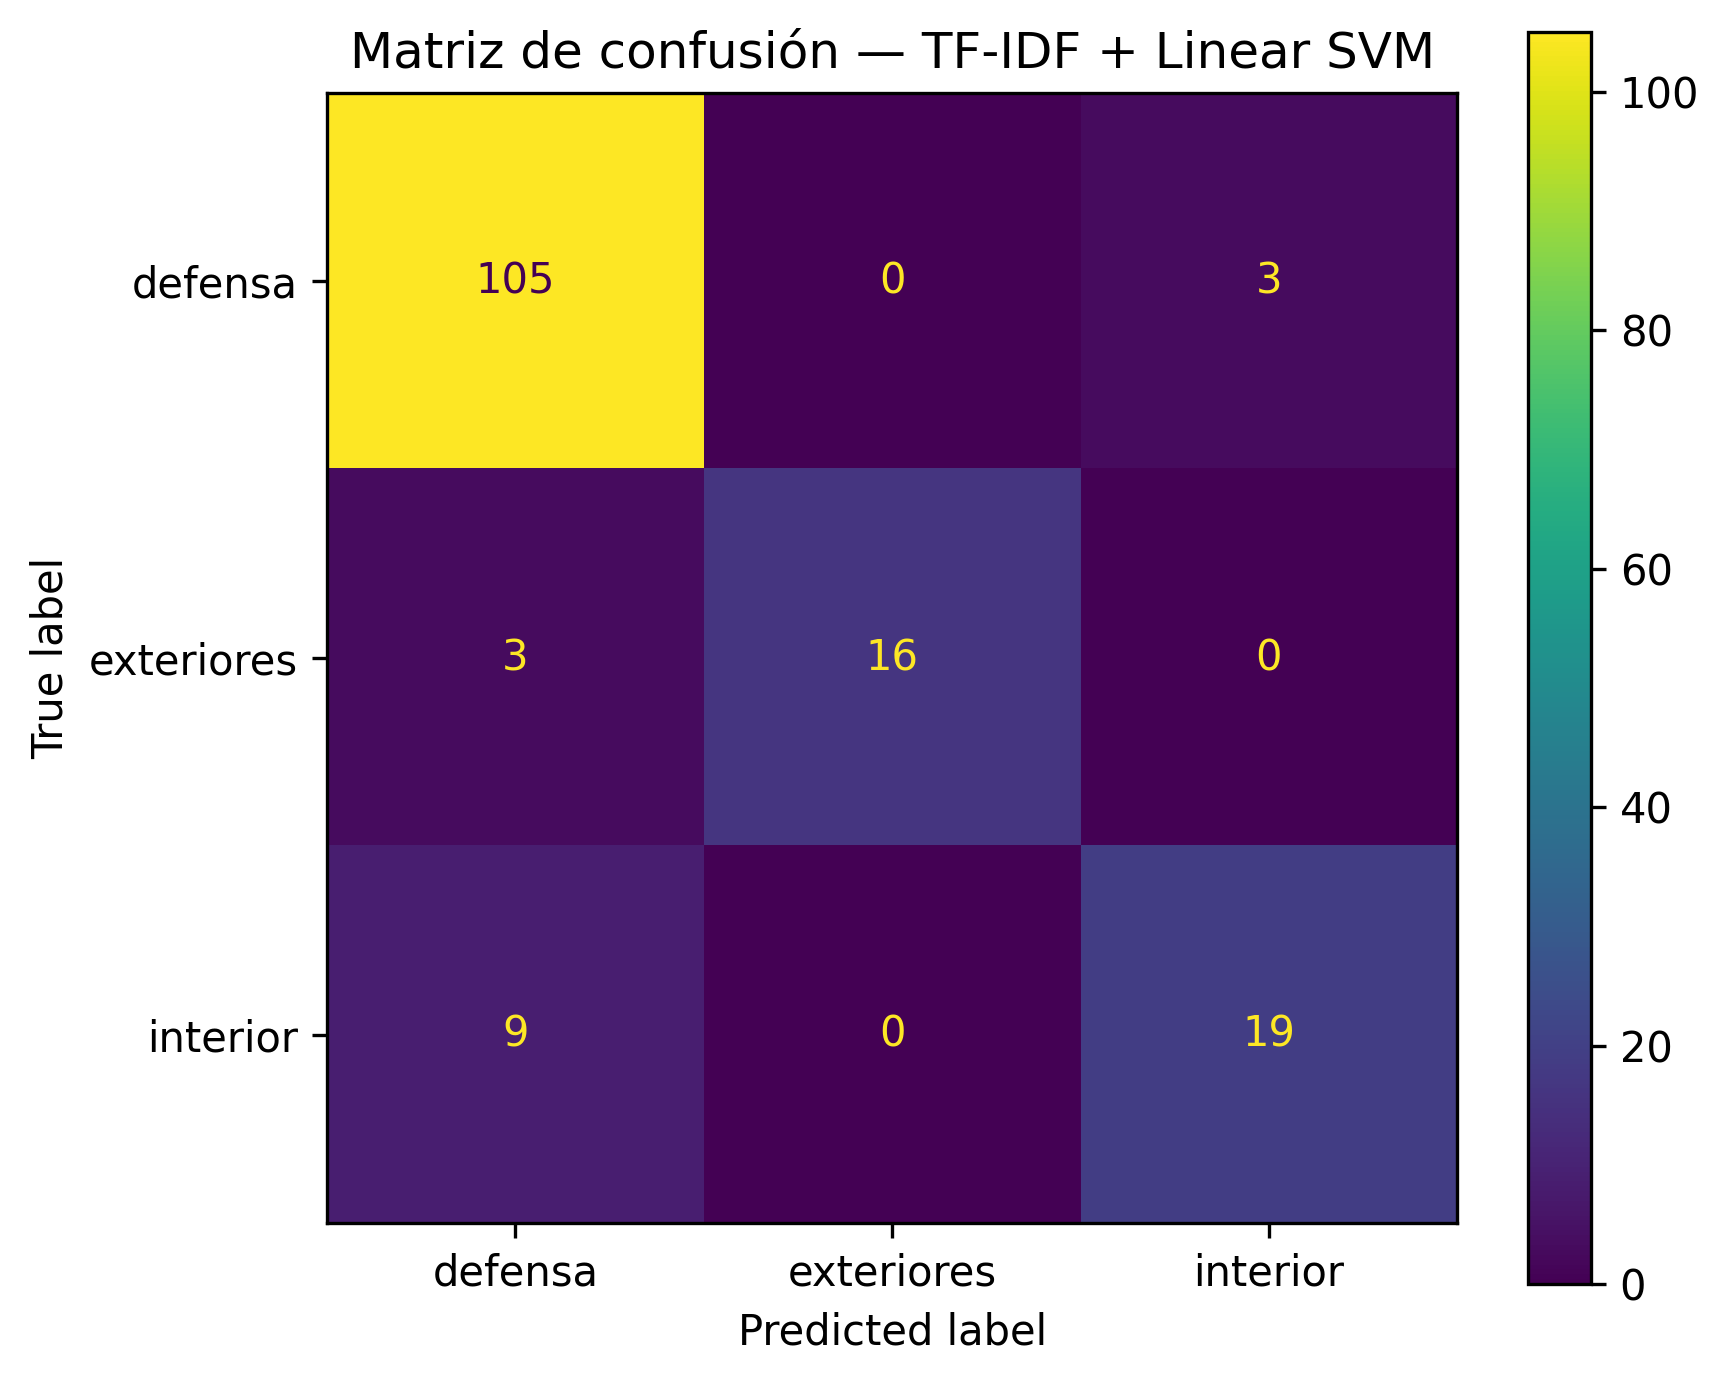

In [6]:
case1_metrics = pd.read_csv(OUTPUT_TABLES_DIR / "caso1_clasificacion_model_metrics.csv")
case1_report = pd.read_csv(OUTPUT_TABLES_DIR / "caso1_clasificacion_report_best_model.csv")
case1_unlabeled = pd.read_csv(OUTPUT_TABLES_DIR / "caso1_clasificacion_unlabeled_predictions.csv")
case1_confusion_path = OUTPUT_FIGURES_DIR / "caso1_clasificacion_confusion_matrix.png"

best_case1_model = case1_metrics.sort_values("f1_macro_mean", ascending=False).iloc[0]
case1_unlabeled_counts = (
    case1_unlabeled["predicted_moncloa_section"]
    .value_counts()
    .rename_axis("predicted_moncloa_section")
    .reset_index(name="n_documents")
)

display(case1_metrics)
display(case1_report)
display(case1_unlabeled_counts)

print(f"Figura validada: {case1_confusion_path.relative_to(PROJECT_ROOT)}")
display(Image(filename=str(case1_confusion_path), width=650))

**Lectura del output.**  
El modelo con mejor `f1_macro` es `TF-IDF + Linear SVM`, con una macro F1 cercana a 0,866. La mejora frente al baseline de clase mayoritaria es clara: el baseline alcanza una macro F1 baja porque predice la clase dominante, mientras que los modelos textuales capturan señal institucional en el contenido.

La matriz de confusión muestra un rendimiento alto en `defensa` y `exteriores`, y una mayor dificultad en `interior`, que se confunde parcialmente con `defensa`. Esta confusión es coherente con el solapamiento semántico entre documentos sobre Guardia Civil, juicio, golpe, FAS o ámbito militar.

La predicción de los documentos sin etiqueta institucional queda también trazada: los 12 documentos no etiquetados se clasifican como `exteriores`, resultado coherente con sus referencias documentales. Para profundizar en términos relevantes y análisis de errores, debe revisarse el notebook `04_caso_uso1_clasificacion_institucional.ipynb`.


## 7. Caso de uso 2 — Clustering temático

El segundo caso aplica clustering sobre el corpus para explorar agrupaciones temáticas sin usar etiquetas institucionales como variable objetivo.

El desarrollo completo está en `notebooks/05_caso_uso2.ipynb`. Aquí se validan las métricas de selección de `k`, los términos representativos, la interpretación manual y la asignación de documentos a clusters.


,k,silhouette_cosine,inertia,cluster_sizes
0,2,0.050408,146.414800,"[119, 48]"
1,3,0.071176,142.011492,"[91, 48, 28]"
2,4,0.082826,138.318122,"[16, 48, 26, 77]"
3,5,0.082478,136.522745,"[48, 66, 6, 19, 28]"
4,6,0.059026,133.699682,"[20, 26, 9, 57, 26, 29]"
5,7,0.076782,131.562488,"[8, 18, 25, 44, 9, 22, 41]"
6,8,0.083508,129.357102,"[15, 42, 63, 10, 8, 9, 9, 11]"


,cluster,n_documentos,porcentaje
0,0,48,28.74
1,1,66,39.52
2,2,6,3.59
3,3,19,11.38
4,4,28,16.77


,cluster,n_documentos,terminos_representativos
0,0,48,"armada, tejero, fiscal, congreso, defensor, civil, guardia, guardia civil, declaración, interrogatorio, defensores, ..."
1,1,66,"golpe, españa, civil, situación, fas, madrid, congreso, partido, grupo, miembros, interior, fuerzas, prensa, guardia..."
2,2,6,"die, majestad, europa, mensaje, exteriores, federal, pueblo, cámara, juan carlos, llorca, embajador, carlos, agradez..."
3,3,19,"spain, spanish, haig, democracy, washington, democratic, reagan, espanha, america, unidos, estados unidos, people, e..."
4,4,28,"justicia, supremo, togado, consejero, consejero togado, defensa, causa, madrid, procesamiento, reunido justicia, sup..."


,cluster,interpretacion,n_documentos,porcentaje
0,0,"Vista oral, Tejero y documentación judicial-militar",48,28.74
1,1,"Informes generales, situación interior y contexto del golpe",66,39.52
2,2,"Documentación exterior, Casa Real y mensajes institucionales",6,3.59
3,3,Exteriores con dimensión internacional y prensa extranjera,19,11.38
4,4,"Justicia militar, Consejo Supremo y documentación procesal",28,16.77


,metric,value
0,best_k_by_silhouette,8
1,best_silhouette_cosine,0.0835
2,n_documents_clustered,167
3,n_clusters_in_assignment,5
4,has_cluster_terms,True
5,has_cluster_interpretation,True


Figura validada: outputs/figures/caso2_clusters_svd.png


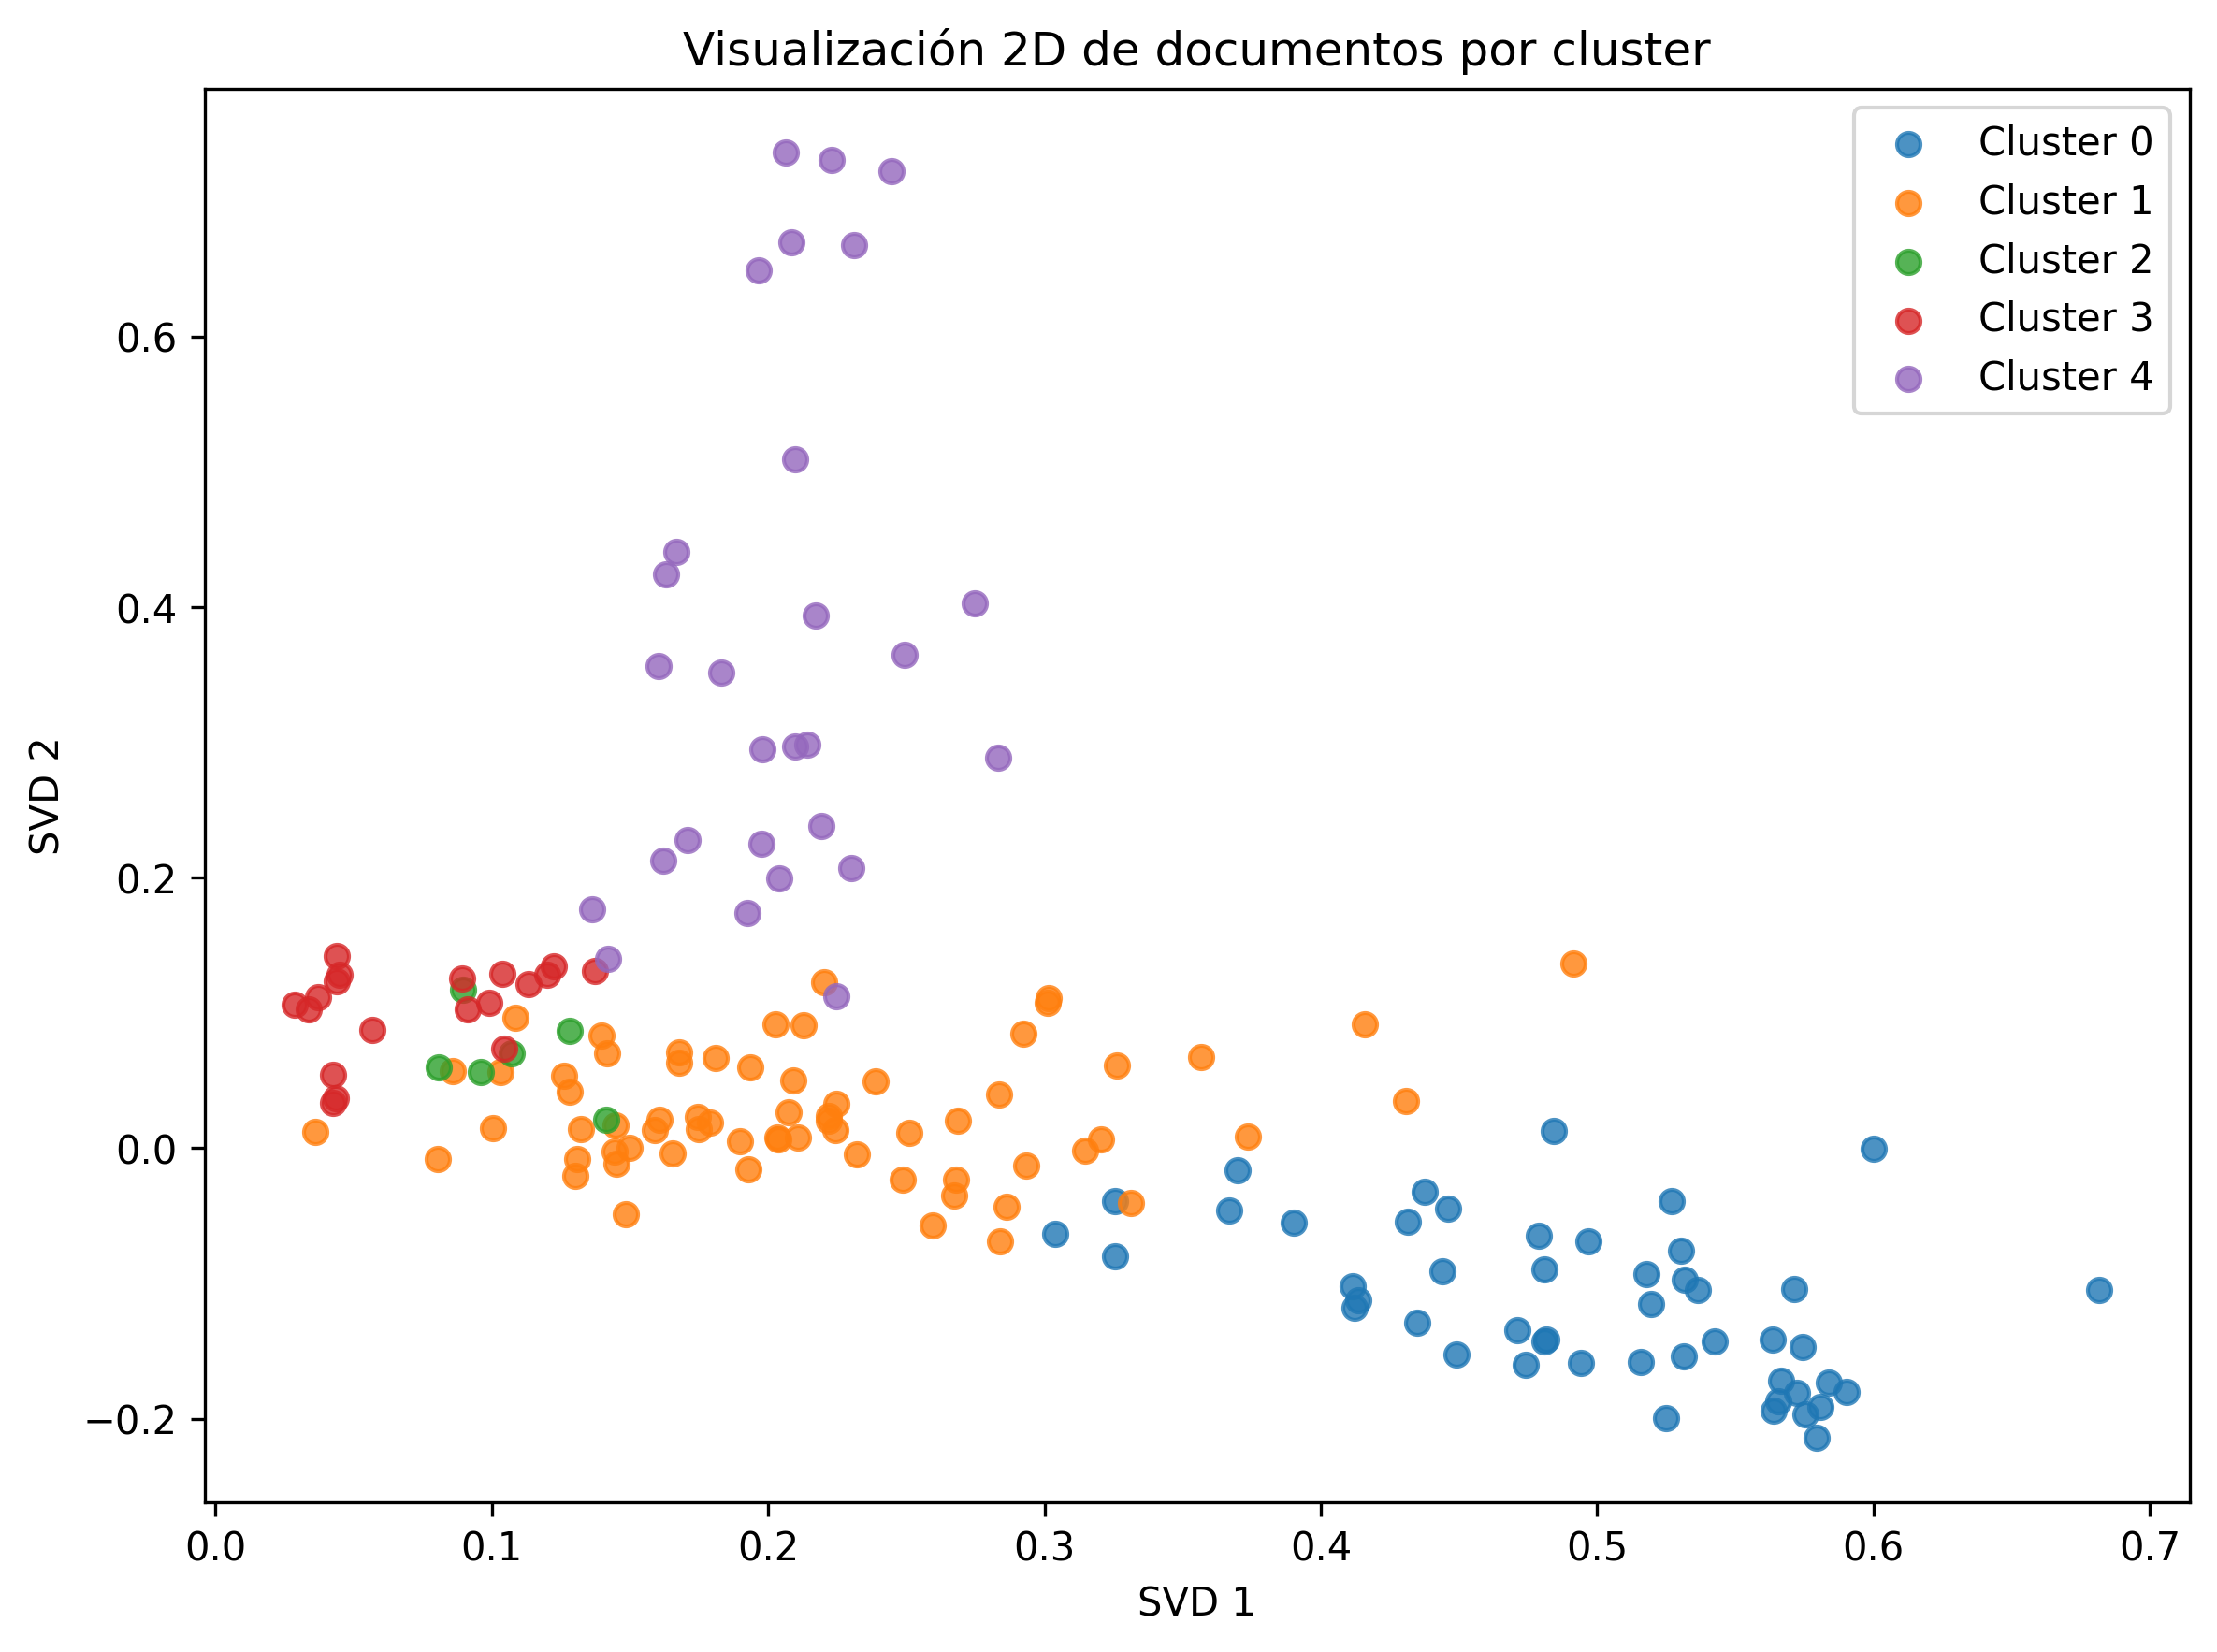

In [7]:
case2_k = pd.read_csv(OUTPUT_TABLES_DIR / "caso2_k_selection_metrics.csv")
case2_summary = pd.read_csv(OUTPUT_TABLES_DIR / "caso2_cluster_summary.csv")
case2_terms = pd.read_csv(OUTPUT_TABLES_DIR / "caso2_cluster_terms.csv")
case2_interpretation = pd.read_csv(OUTPUT_TABLES_DIR / "caso2_cluster_interpretation.csv")
case2_docs = pd.read_csv(OUTPUT_TABLES_DIR / "caso2_document_clusters.csv")
case2_figure_path = OUTPUT_FIGURES_DIR / "caso2_clusters_svd.png"

best_k_row = case2_k.sort_values("silhouette_cosine", ascending=False).iloc[0]

case2_validation = pd.DataFrame({
    "metric": [
        "best_k_by_silhouette",
        "best_silhouette_cosine",
        "n_documents_clustered",
        "n_clusters_in_assignment",
        "has_cluster_terms",
        "has_cluster_interpretation",
    ],
    "value": [
        int(best_k_row["k"]),
        round(float(best_k_row["silhouette_cosine"]), 4),
        len(case2_docs),
        case2_docs["cluster"].nunique() if "cluster" in case2_docs.columns else np.nan,
        len(case2_terms) > 0,
        len(case2_interpretation) > 0,
    ],
})

display(case2_k)
display(case2_summary)
display(case2_terms)
display(case2_interpretation)
display(case2_validation)

print(f"Figura validada: {case2_figure_path.relative_to(PROJECT_ROOT)}")
display(Image(filename=str(case2_figure_path), width=700))

**Lectura del output.**  
La selección de `k` muestra valores de silhouette bajos en términos absolutos, por lo que el clustering debe interpretarse como análisis exploratorio, no como separación temática perfecta. Aun así, la comparación entre valores de `k`, los tamaños de cluster y la interpretación manual permiten extraer agrupaciones útiles.

El caso guarda asignaciones documentales, términos representativos e interpretación de clusters. Esto es importante porque, al ser una tarea no supervisada, la evaluación no puede depender solo de una métrica interna: necesita revisión cualitativa de los términos y de los documentos agrupados.

La figura SVD ayuda a visualizar la estructura de los grupos en dos dimensiones, aunque no debe interpretarse como prueba definitiva de separación. Para el detalle metodológico y la justificación de la selección final, debe consultarse `05_caso_uso2.ipynb`.


## 8. Caso de uso 3 — Grafo de entidades

El tercer caso construye un grafo de coocurrencias entre entidades extraídas del corpus. La finalidad es representar actores, instituciones o lugares como nodos, y sus apariciones conjuntas como relaciones.

El desarrollo completo está en `notebooks/06_caso_uso3.ipynb`. Aquí se validan entidades limpias, aristas, métricas de nodos, resumen del grafo y visualización del subgrafo principal.


,metric,value
0,n_nodes,436.000000
1,n_edges,6728.000000
2,density,0.070948
3,n_connected_components,4.000000
4,largest_component_size,433.000000
5,n_nodes_visual_subgraph,20.000000
6,n_edges_visual_subgraph,76.000000


,entity,label,n_menciones,n_documentos
0,Madrid,LOC,123,76
1,Congreso,ORG,282,57
2,Guardia Civil,ORG,134,52
3,España,PER,75,36
4,General Armada,PER,172,34
5,CESID,ORG,115,32
6,Armada,ORG,73,30
7,Constitución,LOC,47,29
8,Congreso,LOC,49,28
9,España,LOC,43,26


,source,target,weight
0,Congreso,Guardia Civil,39
1,Congreso,España,31
2,Congreso,General Armada,29
3,CESID,Congreso,26
4,España,Madrid,26
5,España,Guardia Civil,26
6,Armada,Congreso,25
7,Constitución,Guardia Civil,24
8,Congreso,Constitución,24
9,Guardia Civil,Madrid,23


,entity,label,n_documentos,degree_centrality,weighted_degree
0,Congreso,ORG,59,0.754023,1586
1,Guardia Civil,ORG,52,0.788506,1451
2,España,PER,58,0.696552,1165
3,Madrid,LOC,82,0.671264,1043
4,General Armada,PER,34,0.533333,925
5,Constitución,LOC,34,0.600000,922
6,Armada,ORG,30,0.487356,847
7,CESID,ORG,32,0.485057,762
8,Valencia,LOC,25,0.450575,722
9,Gobierno,LOC,27,0.379310,537


,metric,value
0,n_entities,4595
1,n_edges,6728
2,n_node_metrics,436
3,has_graph_summary,True


Figura validada: outputs/figures/caso3_subgrafo_principal.png


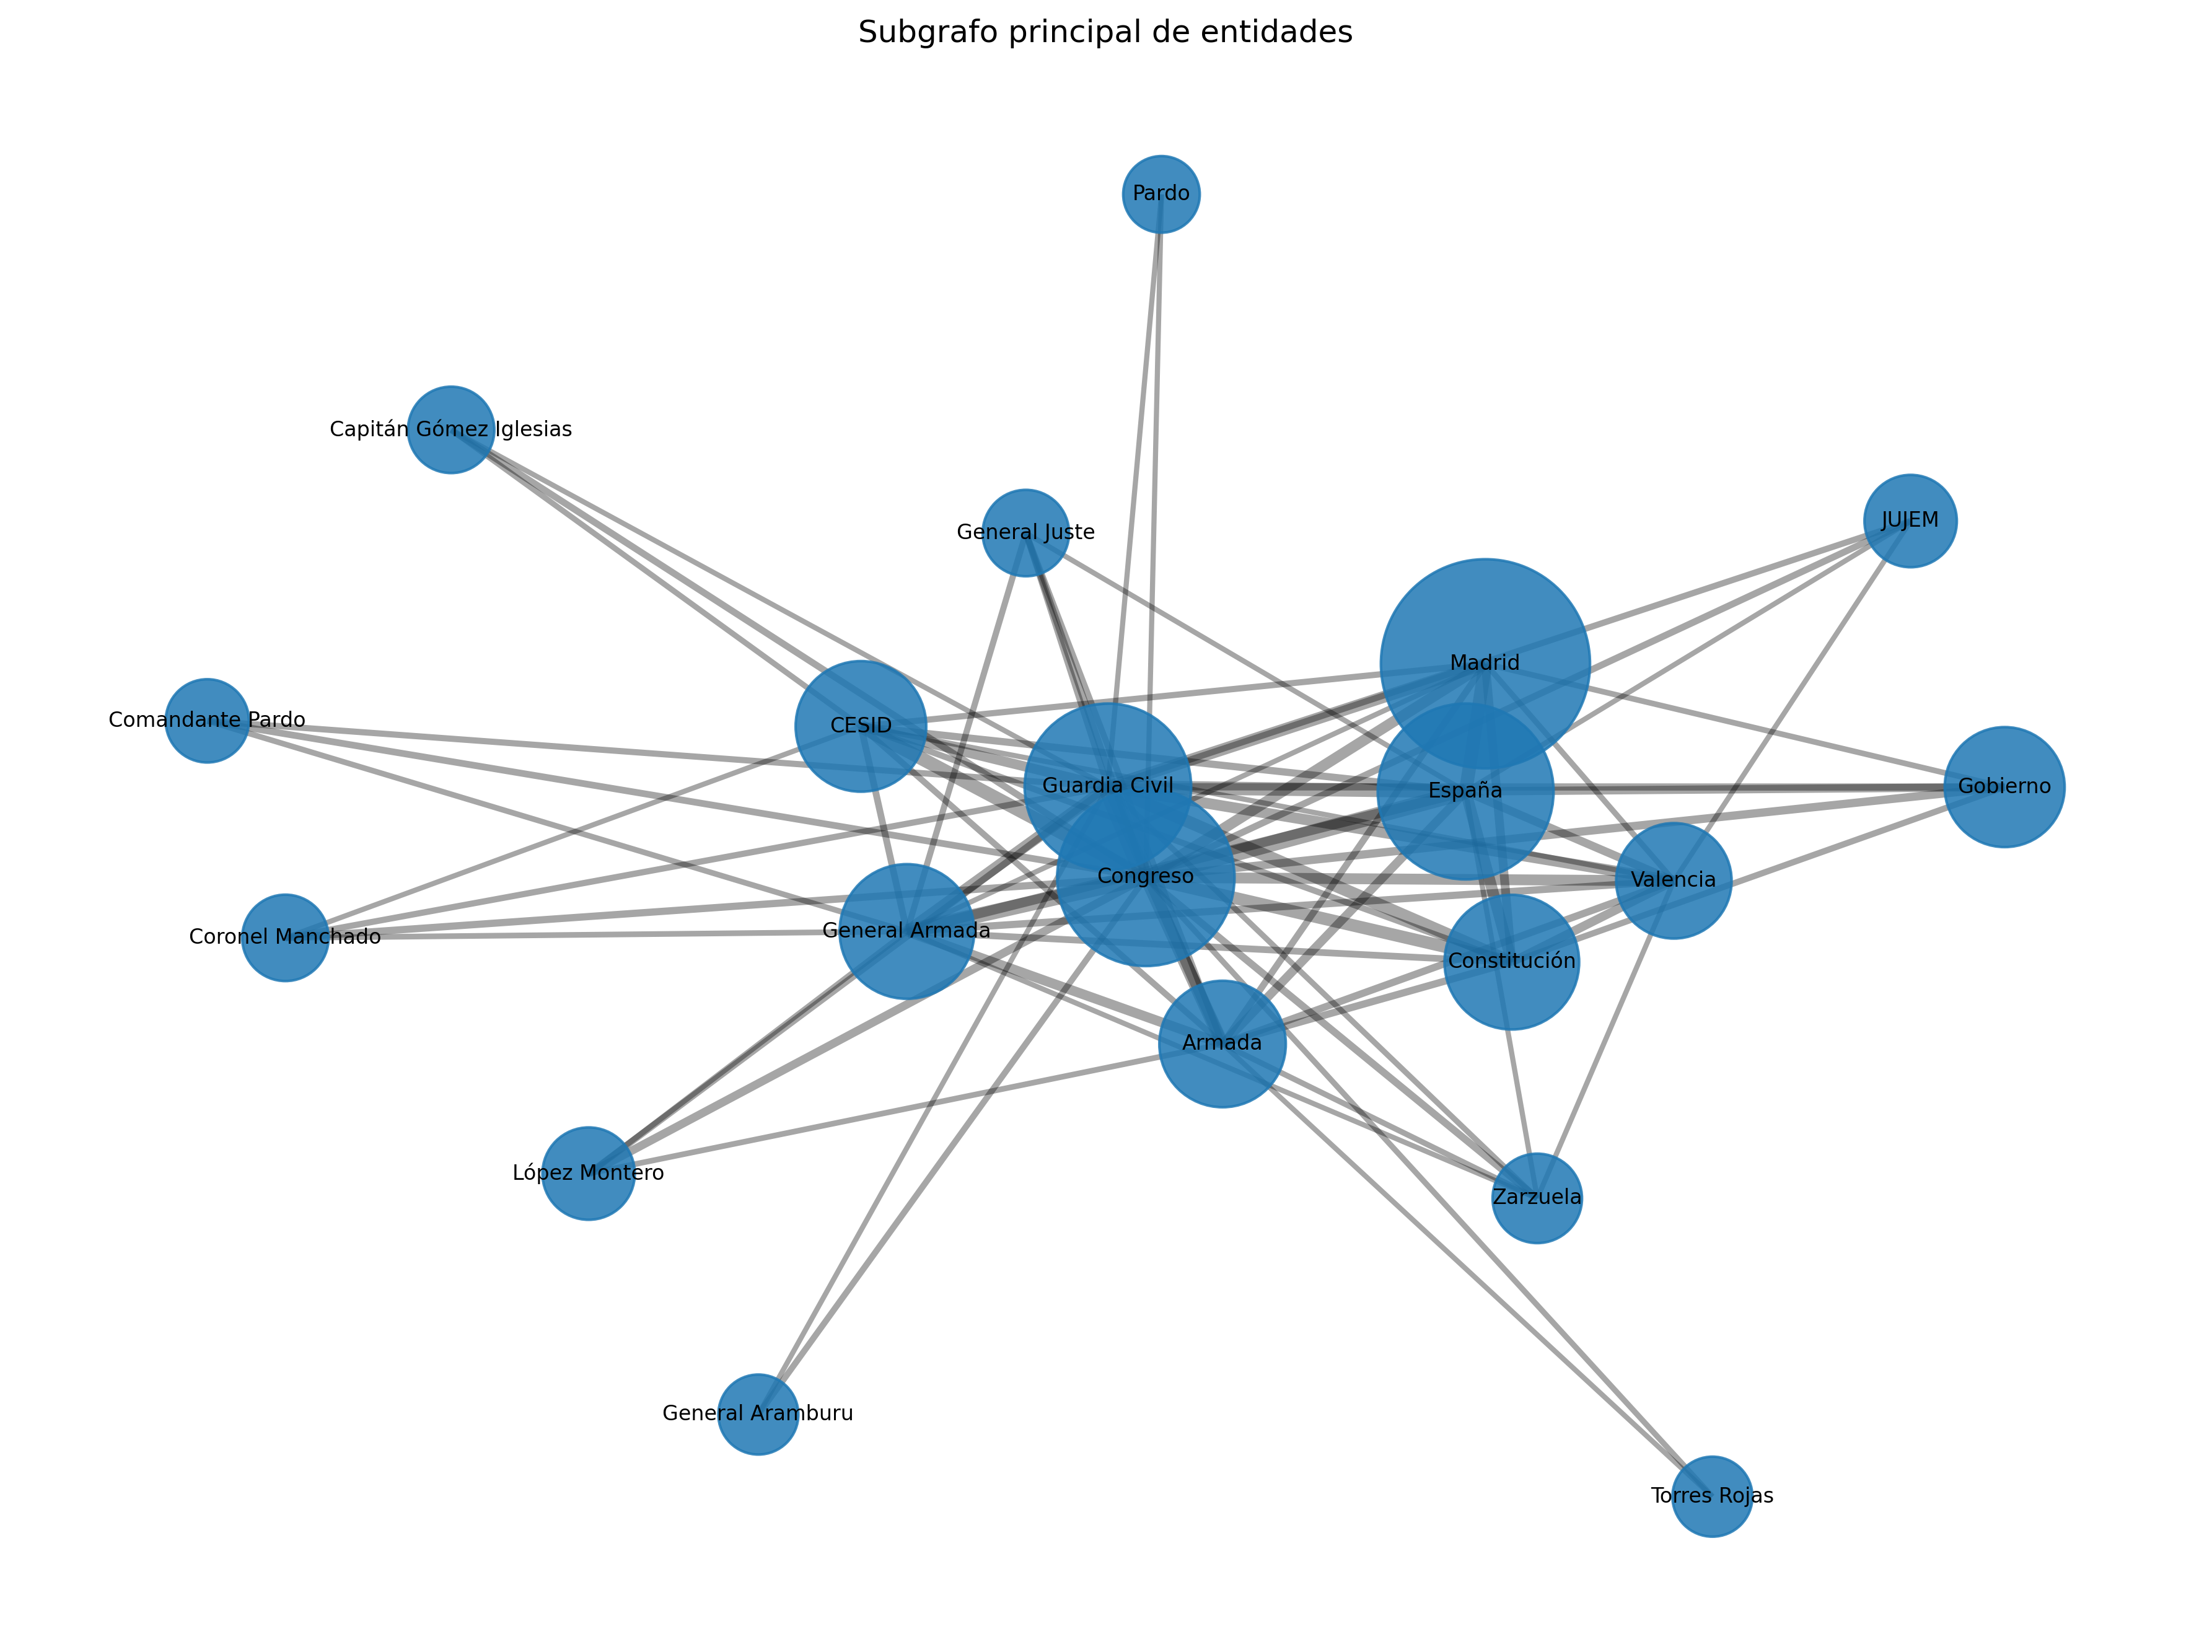

In [8]:
case3_entities = pd.read_csv(OUTPUT_TABLES_DIR / "caso3_entity_frequency_clean.csv")
case3_edges = pd.read_csv(OUTPUT_TABLES_DIR / "caso3_graph_edges.csv")
case3_nodes = pd.read_csv(OUTPUT_TABLES_DIR / "caso3_node_metrics.csv")
case3_summary = pd.read_csv(OUTPUT_TABLES_DIR / "caso3_graph_summary.csv")
case3_figure_path = OUTPUT_FIGURES_DIR / "caso3_subgrafo_principal.png"

display(case3_summary)
display(case3_entities.head(10))
display(case3_edges.head(10))
display(case3_nodes.head(10))

case3_validation = pd.DataFrame({
    "metric": [
        "n_entities",
        "n_edges",
        "n_node_metrics",
        "has_graph_summary",
    ],
    "value": [
        len(case3_entities),
        len(case3_edges),
        len(case3_nodes),
        len(case3_summary) > 0,
    ],
})

display(case3_validation)

print(f"Figura validada: {case3_figure_path.relative_to(PROJECT_ROOT)}")
display(Image(filename=str(case3_figure_path), width=800))

**Lectura del output.**  
El grafo contiene 436 nodos y 6.728 aristas, con una componente principal muy dominante. Esto indica que el corpus genera una red relacional densa, en la que la mayoría de entidades relevantes están conectadas directa o indirectamente.

El subgrafo visualizado reduce esa complejidad para mostrar las entidades más importantes, pero no sustituye al grafo completo. La tabla de métricas de nodos permite identificar actores o instituciones centrales, mientras que la tabla de aristas conserva la trazabilidad de relaciones.

La lectura debe mantenerse exploratoria: las aristas reflejan coocurrencia documental, no necesariamente relación causal o histórica directa. Para revisar el filtrado de entidades, construcción de relaciones y decisiones de visualización, debe consultarse `06_caso_uso3.ipynb`.


## 9. Caso de uso 4 — Asistente documental semántico

El cuarto caso desarrolla una aproximación de búsqueda semántica sobre fragmentos del corpus. El objetivo es recuperar documentos o fragmentos relevantes a partir de consultas del usuario, manteniendo trazabilidad mediante `doc_id`, título, sección y score.

El desarrollo completo está en `notebooks/07_caso_uso4_asistente_semantico.ipynb`. Aquí se revisan ejemplos de búsqueda y la evaluación mediante `recall@k`.


,consulta,rank,score,doc_id,seccion,title
0,¿Qué documentos mencionan al CESID?,1,0.1243,rtve_1860,defensa,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero
1,¿Qué documentos mencionan al CESID?,2,0.1007,rtve_1743,exteriores,D.1._AGMAE_R39017_Exp._4
2,¿Qué documentos mencionan al CESID?,3,0.0919,rtve_1698,interior,Documento manuscrito de posible planificación del golpe.
3,¿Qué aparece sobre Tejero en las vistas orales?,1,0.0856,rtve_1699,interior,Transcripción de cintas grabadas con conversaciones telefónicas con va
4,¿Qué aparece sobre Tejero en las vistas orales?,2,0.0713,rtve_1784,interior,Policía Nacional. Informe de situación. Marca: reservado-confidencial
5,¿Qué aparece sobre Tejero en las vistas orales?,3,0.0706,rtve_1767,interior,"""Informe de las distintas Jefaturas Superiores: Comisaría General de I"
6,¿Qué documentos hablan de la Guardia Civil?,1,0.0807,rtve_1743,exteriores,D.1._AGMAE_R39017_Exp._4
7,¿Qué documentos hablan de la Guardia Civil?,2,0.0736,rtve_1698,interior,Documento manuscrito de posible planificación del golpe.
8,¿Qué documentos hablan de la Guardia Civil?,3,0.0681,rtve_1696,interior,Conversaciones telefónicas de (presuntamente) la unidad militar El Par
9,¿Qué documentos tratan sobre la sentencia?,1,0.0970,rtve_1743,exteriores,D.1._AGMAE_R39017_Exp._4


,metric,value
0,n_search_results_examples,15
1,n_unique_queries,5
2,max_rank,3
3,has_recall_figure,True


Figura validada: outputs/figures/caso4_recall_at_k.png


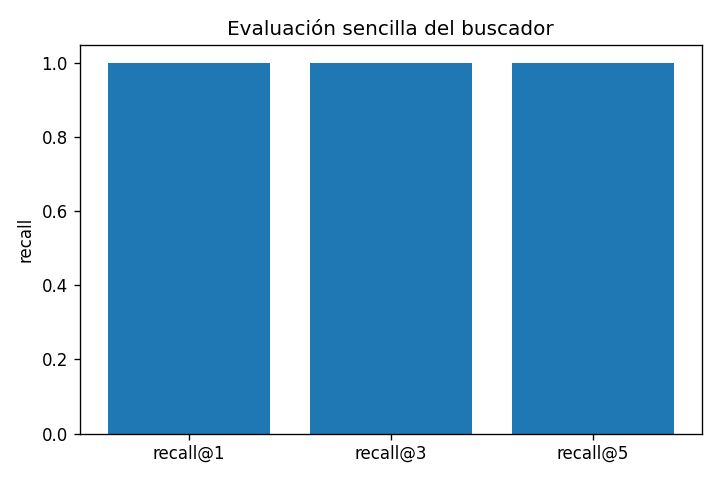

In [9]:
case4_examples = pd.read_csv(OUTPUT_TABLES_DIR / "caso4_busqueda_ejemplos.csv")
case4_figure_path = OUTPUT_FIGURES_DIR / "caso4_recall_at_k.png"

query_col = "consulta" if "consulta" in case4_examples.columns else "query" if "query" in case4_examples.columns else None

case4_validation = pd.DataFrame({
    "metric": [
        "n_search_results_examples",
        "n_unique_queries",
        "max_rank",
        "has_recall_figure",
    ],
    "value": [
        len(case4_examples),
        case4_examples[query_col].nunique() if query_col else np.nan,
        case4_examples["rank"].max() if "rank" in case4_examples.columns else np.nan,
        case4_figure_path.exists(),
    ],
})

display(case4_examples.head(10))
display(case4_validation)

print(f"Figura validada: {case4_figure_path.relative_to(PROJECT_ROOT)}")
display(Image(filename=str(case4_figure_path), width=700))

**Lectura del output.**  
Los ejemplos muestran que el sistema devuelve resultados trazables por consulta, con ranking, score, `doc_id`, sección y título. Esto permite inspeccionar manualmente si la recuperación es razonable y evita que el asistente funcione como una caja negra.

La figura de `recall@k` resume la calidad de recuperación para distintos valores de `k`. En este tipo de caso, la evaluación no debe limitarse a una única métrica: también importa que el resultado mantenga evidencia documental y permita revisión humana.

Para revisar la fragmentación del corpus, el vectorizador utilizado y los ejemplos completos de consulta, debe consultarse `07_caso_uso4_asistente_semantico.ipynb`.


## 10. Caso de uso 5 — Fichas documentales

El quinto caso genera fichas o resúmenes estructurados para facilitar la consulta del corpus. Su objetivo es enriquecer cada documento con una representación más manejable, manteniendo trazabilidad al texto original.

El desarrollo completo está en `notebooks/08_caso_uso5_fichas_documentales.ipynb`. Aquí se validan estados de generación, métodos usados, muestra de revisión manual y dataset final de fichas.


,summary_status,n_documents
0,ok_llm,112
1,ok_hibrido_por_error_llm,55


,summary_method,n_documents
0,llm_github_rewrite_with_hybrid_fallback,112
1,hybrid_fallback_after_llm_error,55


,length_bucket,doc_id,title,summary_original,summary_seed_clean,resumen_corto,resumen_extendido,summary_method,summary_status,summary_error,n_evidence_sentences,text_clean_length_words,pdf_url
0,corto_<300,rtve_1726,RESERVADO: comunicación procesamiento implicado.,"El documento es una comunicación oficial del Consejo Supremo de Justicia Militar, fechada el 10 de abril de 1981, di...","El documento es una comunicación oficial del Consejo Supremo de Justicia Militar, fechada el 10 de abril de 1981, di...","El documento es una comunicación oficial del Consejo Supremo de Justicia Militar, fechada el 10 de abril de 1981, di...",El documento constituye una comunicación oficial emitida por el Consejo Supremo de Justicia Militar el 10 de abril d...,llm_github_rewrite_with_hybrid_fallback,ok_llm,NaN,4,154,https://www.rtve.es/contenidos/documentos/23f-desclasificado/122_2026_reservado_comunicacion_procesamiento_implicado...
1,corto_<300,rtve_1761,D.17._AGMAE_R40201_Exp._215,La página 1 presenta una comunicación oficial de la Cámara Municipal de Campo Maior dirigida al Cónsul de España en ...,La página 1 presenta una comunicación oficial de la Cámara Municipal de Campo Maior dirigida al Cónsul de España en ...,La página 1 presenta una comunicación oficial de la Cámara Municipal de Campo Maior dirigida al Cónsul de España en ...,La página 1 presenta una comunicación oficial de la Cámara Municipal de Campo Maior dirigida al Cónsul de España en ...,hybrid_fallback_after_llm_error,ok_hibrido_por_error_llm,"HTTP 429: Too many requests. For more on scraping GitHub and how it may affect your rights, please review our Terms ...",2,169,https://www.rtve.es/contenidos/documentos/23f-desclasificado/154_2026_d17_agmae_r40201_exp_215.pdf
2,largo_1000_2999,rtve_1823,Vista oral 2/81 del Consejo Supremo de Justicia Militar (28 de abril de 1982).,"Las páginas resumen la vista oral 2/81 del Consejo Supremo de Justicia Militar, celebrada el 28 de abril de 1982, en...","Las páginas resumen la vista oral 2/81 del Consejo Supremo de Justicia Militar, celebrada el 28 de abril de 1982, en...","La vista oral 2/81 del Consejo Supremo de Justicia Militar, celebrada el 28 de abril de 1982, abordó el proceso por ...","La sesión 2/81 del Consejo Supremo de Justicia Militar se inició a las 10:06 horas el 28 de abril de 1982, con la in...",llm_github_rewrite_with_hybrid_fallback,ok_llm,NaN,7,1670,https://www.rtve.es/contenidos/documentos/23f-desclasificado/62_1982_vista_oral_281_del_consejo_supremo_de_justicia_...
3,largo_1000_2999,rtve_1776,D.31._AGA-83-09301_exp._5,El conjunto de documentos refleja la respuesta unánime y activa del Parlamento británico y del Partido Laborista tra...,El conjunto de documentos refleja la respuesta unánime y activa del Parlamento británico y del Partido Laborista tra...,El conjunto de documentos refleja la respuesta unánime y activa del Parlamento británico y del Partido Laborista tra...,El conjunto de documentos refleja la respuesta unánime y activa del Parlamento británico y del Partido Laborista tra...,hybrid_fallback_after_llm_error,ok_hibrido_por_error_llm,"HTTP 429: Too many requests. For more on scraping GitHub and how it may affect your rights, please review our Terms ...",7,1926,https://www.rtve.es/contenidos/documentos/23f-desclasificado/168_2026_d31_aga_83_09301_exp_5.pdf
4,medio_300_999,rtve_1712,Oficio zona País Vasco que expresa una comunicación del teniente coronel Tejero sobre la posible situación de tensió...,El informe reservado de la Dirección General de la Guardia Civil sobre el Teniente Coronel Antonio Tejero Molina señ...,El informe reservado de la Dirección General de la Guardia Civil sobre el Teniente Coronel Antonio Tejero Molina señ...,El informe reservado de la Dirección General de la Guardia Civil sobre el Teniente Coronel Antonio Tejero Molina señ...,El informe reservado de la Dirección General de la Guardia Civil sobre el Teniente Coronel Antonio Tejero Molina señ...,hybrid_fallback_after_llm_error,ok_hibrid

,doc_id,title,summary_original,summary_seed_clean,resumen_corto,resumen_extendido,summary_method,summary_status,summary_error,llm_attempted,n_evidence_sentences,evidence_sentences_json,n_llm_chunks,text_clean_length_words,moncloa_section,pdf_url
0,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,"El juicio oral 2/81 celebrado en febrero de 1982 se caracterizó por un intenso desarrollo en sus primeras sesiones, ...","El juicio oral 2/81 celebrado en febrero de 1982 se caracterizó por un intenso desarrollo en sus primeras sesiones, ...","El juicio oral 2/81, celebrado en febrero de 1982, se desarrolló con sesiones intensas y controversias sobre la inte...","El juicio oral 2/81, llevado a cabo en febrero de 1982, se caracterizó por un desarrollo intenso en sus primeras ses...",llm_github_rewrite_with_hybrid_fallback,ok_llm,NaN,True,7,"[""1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82"", ""La vista se interrumpió hasta las 10,00 horas del lunes...",1,640,defensa,https://www.rtve.es/contenidos/documentos/23f-desclasificado/99_1982_vista_oral_281_del_consejo_supremo_de_justicia_...
1,rtve_1859,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,Resumen global del documento:\n\nEl documento recoge el desarrollo de una serie de sesiones celebradas el 22 de febr...,El documento recoge el desarrollo de una serie de sesiones celebradas el 22 de febrero de 1982 por el Consejo Suprem...,"El 22 de febrero de 1982, el Consejo Supremo de Justicia Militar celebró una vista oral en la que se analizaron decl...",El documento recoge el desarrollo de la vista oral celebrada el 22 de febrero de 1982 por el Consejo Supremo de Just...,llm_github_rewrite_with_hybrid_fallback,ok_llm,NaN,True,7,"[""1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 22-02-82."", ""- A las 12'09 el PRESIDENTE DEL CONSEJO suspende la vi...",1,1018,defensa,https://www.rtve.es/contenidos/documentos/23f-desclasificado/98_1982_vista_oral_281_del_consejo_supremo_de_justicia_...
2,rtve_1858,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,Resumen global del documento:\n\nEl documento narra el desarrollo tenso y conflictivo de una serie de sesiones del C...,El documento narra el desarrollo tenso y conflictivo de una serie de sesiones del Consejo Supremo de Justicia Milita...,"El documento relata las tensas sesiones del Consejo Supremo de Justicia Militar en febrero de 1982, centradas en la ...",El documento describe el desarrollo conflictivo de las sesiones del Consejo Supremo de Justicia Militar el 23 de feb...,llm_github_rewrite_with_hybrid_fallback,ok_llm,NaN,True,7,"[""## 1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 23.02.82"", ""La última noticia es que la condición impuesta por l...",1,1347,defensa,https://www.rtve.es/contenidos/documentos/23f-desclasificado/97_1982_vista_oral_281_del_consejo_supremo_de_justicia_...
3,rtve_1857,Vista oral 2/81 del Consejo Supremo de Justicia Militar (25 de febrero de 1982).,El documento recoge el desarrollo de la sesión del Consejo Supremo de Justicia Militar en febrero de 1982 relativa a...,El documento recoge el desarrollo de la sesión del Consejo Supremo de Justicia Militar en febrero de 1982 relativa a...,"El documento recoge la sesión del Consejo Supremo de Justicia Militar del 24 de febrero de 1982, en el juicio por lo...","La vista oral 2/81 del Consejo Supremo de Justicia Militar, celebrada el 24 de febrero de 1982, se centra en el juic...",llm_github_rewrite_with_hybrid_fallback,ok_llm,NaN,True,7,"[""ASUNTO: Vista Oral 2/81 del Consejo Supremo de Justicia Militar."", ""## 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE...",1,1826,defensa,https://www.rtve.es/contenidos/documentos/23f-desclasificado/96_1982_vista_oral_281_del_consejo_supremo_de_justicia_...
4,rtve_1856,Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de febrero de 1982).,Resumen global del documento sobre la sesión del Consejo Supremo de Justicia Milit

,metric,value
0,n_summaries,167
1,n_status_rows,2
2,n_method_rows,2
3,n_manual_review_rows,8
4,has_method_figure,True


Figura validada: outputs/figures/caso_uso5_metodo_por_longitud.png


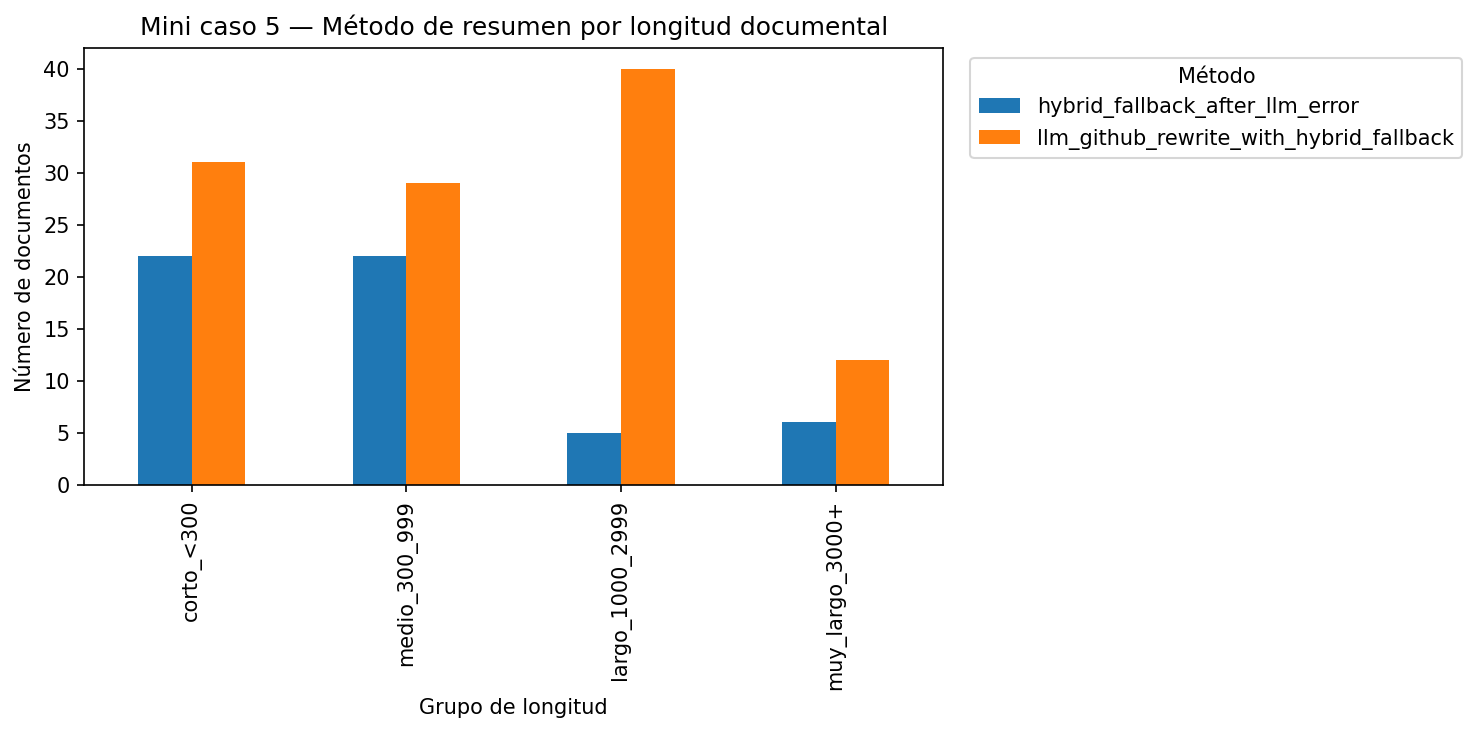

In [10]:
case5_status = pd.read_csv(OUTPUT_TABLES_DIR / "caso_uso5_resumen_estados.csv")
case5_methods = pd.read_csv(OUTPUT_TABLES_DIR / "caso_uso5_resumen_metodos.csv")
case5_review = pd.read_csv(OUTPUT_TABLES_DIR / "caso_uso5_muestra_revision_manual.csv")
case5_summaries_path = DATA_PROCESSED_DIR / "rtve_documentary_summaries_case5.csv"
case5_summaries = pd.read_csv(case5_summaries_path)
case5_figure_path = OUTPUT_FIGURES_DIR / "caso_uso5_metodo_por_longitud.png"

display(case5_status)
display(case5_methods)
display(case5_review.head())
display(case5_summaries.head())

case5_validation = pd.DataFrame({
    "metric": [
        "n_summaries",
        "n_status_rows",
        "n_method_rows",
        "n_manual_review_rows",
        "has_method_figure",
    ],
    "value": [
        len(case5_summaries),
        len(case5_status),
        len(case5_methods),
        len(case5_review),
        case5_figure_path.exists(),
    ],
})

display(case5_validation)

print(f"Figura validada: {case5_figure_path.relative_to(PROJECT_ROOT)}")
display(Image(filename=str(case5_figure_path), width=700))

**Lectura del output.**  
El caso 5 genera fichas para los 167 documentos del corpus. La tabla de estados muestra que una parte se ha producido directamente mediante LLM y otra mediante un enfoque híbrido de respaldo, lo que evita dejar documentos sin ficha cuando el método principal no es suficiente.

La muestra de revisión manual permite auditar ejemplos concretos, y la figura por método ayuda a entender cómo se distribuye la generación según la longitud documental. Este caso funciona como capa transversal de enriquecimiento, útil para consulta, informe y posibles aplicaciones posteriores.

Para revisar prompts, fallback, criterios de longitud y muestras completas, debe consultarse `08_caso_uso5_fichas_documentales.ipynb`.


## 11. Resumen agregado de outputs oficiales

En lugar de mostrar una tabla larga con todos los archivos, se resume cuántos outputs oficiales existen por bloque y tipo.

El objetivo es mantener trazabilidad sin saturar el notebook con una lista extensa de rutas. Si se necesita revisar cada archivo concreto, están disponibles en `outputs/tables/` y `outputs/figures/`.


In [11]:
output_files = []

for folder, output_type in [
    (OUTPUT_TABLES_DIR, "table"),
    (OUTPUT_FIGURES_DIR, "figure"),
]:
    for path in sorted(folder.glob("*")):
        if path.is_file():
            output_files.append({
                "output_type": output_type,
                "path": str(path.relative_to(PROJECT_ROOT)),
                "filename": path.name,
                "size_bytes": path.stat().st_size,
            })

outputs_manifest = pd.DataFrame(output_files)

def infer_block_from_filename(filename):
    if filename.startswith("caso1_"):
        return "Caso 1 — Clasificación institucional"
    if filename.startswith("caso2_"):
        return "Caso 2 — Clustering temático"
    if filename.startswith("caso3_"):
        return "Caso 3 — Grafo de entidades"
    if filename.startswith("caso4_"):
        return "Caso 4 — Asistente semántico"
    if filename.startswith("caso_uso5_"):
        return "Caso 5 — Fichas documentales"
    if filename.startswith("eda_") or filename.startswith("rtve_corpus_"):
        return "Fase común — EDA / limpieza"
    if filename.startswith("figura_A"):
        return "Documentación / anexos"
    return "Otros"

outputs_manifest["block"] = outputs_manifest["filename"].apply(infer_block_from_filename)

outputs_summary = (
    outputs_manifest
    .groupby(["block", "output_type"])
    .agg(
        n_files=("filename", "count"),
        total_size_kb=("size_bytes", lambda x: round(x.sum() / 1024, 1)),
        example_files=("filename", lambda x: ", ".join(list(x.head(3)))),
    )
    .reset_index()
    .sort_values(["block", "output_type"])
)

display(outputs_summary)

,block,output_type,n_files,total_size_kb,example_files
0,Caso 1 — Clasificación institucional,figure,1,80.5,caso1_clasificacion_confusion_matrix.png
1,Caso 1 — Clasificación institucional,table,6,14.5,"caso1_clasificacion_confusion_matrix.csv, caso1_clasificacion_errors_for_review.csv, caso1_clasificacion_model_metri..."
2,Caso 2 — Clustering temático,figure,1,227.3,caso2_clusters_svd.png
3,Caso 2 — Clustering temático,table,6,40.8,"caso2_cluster_interpretation.csv, caso2_cluster_summary.csv, caso2_cluster_svd_coordinates.csv"
4,Caso 3 — Grafo de entidades,figure,1,743.7,caso3_subgrafo_principal.png
5,Caso 3 — Grafo de entidades,table,4,308.8,"caso3_entity_frequency_clean.csv, caso3_graph_edges.csv, caso3_graph_summary.csv"
6,Caso 4 — Asistente semántico,figure,1,14.5,caso4_recall_at_k.png
7,Caso 4 — Asistente semántico,table,1,2.0,caso4_busqueda_ejemplos.csv
8,Caso 5 — Fichas documentales,figure,1,54.8,caso_uso5_metodo_por_longitud.png
9,Caso 5 — Fichas documentales,table,3,19.9,"caso_uso5_muestra_revision_manual.csv, caso_uso5_resumen_estados.csv, caso_uso5_resumen_metodos.csv"


**Lectura del output.**  
El resumen agregado permite comprobar de forma compacta que los resultados del proyecto están distribuidos por fase y por caso de uso. En lugar de listar todos los archivos uno a uno, la tabla resume cuántas tablas y figuras existen para cada bloque, su tamaño aproximado y algunos ejemplos representativos.

La lectura principal es que los cinco mini casos tienen outputs oficiales versionados en `outputs/tables/` y/o `outputs/figures/`. Esto refuerza la trazabilidad del proyecto: los resultados no quedan únicamente dentro de los notebooks, sino que se guardan como archivos reutilizables para el informe.

También se mantiene una separación útil entre carpetas: `data/processed/` conserva datasets procesados reutilizables, mientras que `outputs/` almacena resultados derivados de análisis, modelos, visualizaciones o validaciones. Esta distinción evita mezclar datos base con resultados interpretativos.

La siguiente comprobación lógica es verificar que el repositorio no contiene rutas absolutas en el código o Markdown de los notebooks versionados, ya que la entrega debe poder ejecutarse en otro ordenador sin modificar rutas.


## 12. Comprobación de rutas absolutas

Se revisa que el código y Markdown de los notebooks versionados no contengan rutas locales dependientes de un ordenador concreto.

La comprobación ignora outputs antiguos guardados dentro del JSON de los notebooks, porque esos outputs pueden contener trazas históricas no ejecutadas. Lo relevante para reproducibilidad es que el código activo y la documentación no dependan de rutas locales.


In [12]:
import nbformat

absolute_path_patterns = [
    "/" + "Users" + "/",
    "Desktop" + "/" + "Big Data",
    "/" + "mnt" + "/" + "data",
    "C:" + "\\\\",
]

absolute_path_matches = []

for notebook_path in sorted(NOTEBOOKS_DIR.rglob("*.ipynb")):
    if ".ipynb_checkpoints" in notebook_path.parts:
        continue
    
    notebook = nbformat.read(notebook_path, as_version=4)
    
    for cell_idx, cell in enumerate(notebook.cells):
        source = cell.get("source", "")
        
        for line_number, line in enumerate(source.splitlines(), start=1):
            if any(pattern in line for pattern in absolute_path_patterns):
                absolute_path_matches.append({
                    "file": str(notebook_path.relative_to(PROJECT_ROOT)),
                    "cell": cell_idx,
                    "line": line_number,
                    "excerpt": line[:200],
                })

absolute_paths_df = pd.DataFrame(absolute_path_matches)

if absolute_paths_df.empty:
    print("Validación superada: no se han detectado rutas absolutas en el código ni Markdown de los notebooks.")
else:
    display(absolute_paths_df)
    raise ValueError(
        "Se han encontrado rutas absolutas en el código o Markdown de notebooks. "
        "Revisar la tabla anterior antes de cerrar la entrega."
    )

Validación superada: no se han detectado rutas absolutas en el código ni Markdown de los notebooks.


**Lectura del output.**  
La validación no detecta rutas absolutas en el código ni en el Markdown de los notebooks versionados. Esto refuerza que la entrega puede ejecutarse en otro ordenador siempre que se conserve la estructura del repositorio.


## 13. Validaciones finales de ejecución

Como cierre técnico, se agrupan las comprobaciones principales del notebook: existencia de notebooks, corpus limpio, datasets procesados, outputs oficiales, figuras y rutas relativas.

Esta tabla no sustituye la revisión del profesor; simplemente resume si el repositorio supera las validaciones necesarias para que este notebook pueda ejecutarse de principio a fin.


In [13]:
final_checks = pd.DataFrame([
    {
        "check": "Existen notebooks 00–08",
        "passed": all((NOTEBOOKS_DIR / filename).exists() for filename in required_notebooks),
    },
    {
        "check": "Existe corpus limpio principal",
        "passed": corpus_path.exists() and len(df_corpus) > 0,
    },
    {
        "check": "Corpus limpio sin textos vacíos",
        "passed": (df_corpus["text_clean_base"].fillna("").str.strip() == "").sum() == 0,
    },
    {
        "check": "Existen datasets procesados obligatorios",
        "passed": all((DATA_PROCESSED_DIR / filename).exists() for filename in required_processed_files),
    },
    {
        "check": "Existen tablas oficiales obligatorias",
        "passed": all((OUTPUT_TABLES_DIR / filename).exists() for filename in required_output_tables),
    },
    {
        "check": "Existen figuras oficiales obligatorias",
        "passed": all((OUTPUT_FIGURES_DIR / filename).exists() for filename in required_output_figures),
    },
    {
        "check": "No se detectan rutas absolutas en notebooks",
        "passed": absolute_paths_df.empty,
    },
    {
        "check": "Caso 1 validado",
        "passed": len(case1_metrics) > 0 and case1_confusion_path.exists(),
    },
    {
        "check": "Caso 2 validado",
        "passed": len(case2_docs) > 0 and case2_figure_path.exists(),
    },
    {
        "check": "Caso 3 validado",
        "passed": len(case3_edges) > 0 and case3_figure_path.exists(),
    },
    {
        "check": "Caso 4 validado",
        "passed": len(case4_examples) > 0 and case4_figure_path.exists(),
    },
    {
        "check": "Caso 5 validado",
        "passed": len(case5_summaries) > 0 and case5_figure_path.exists(),
    },
])

display(final_checks)

if not final_checks["passed"].all():
    failed = final_checks[~final_checks["passed"]]["check"].tolist()
    raise ValueError(
        "No se cumplen todas las validaciones finales:\n"
        + "\n".join(failed)
    )

,check,passed
0,Existen notebooks 00–08,True
1,Existe corpus limpio principal,True
2,Corpus limpio sin textos vacíos,True
3,Existen datasets procesados obligatorios,True
4,Existen tablas oficiales obligatorias,True
5,Existen figuras oficiales obligatorias,True
6,No se detectan rutas absolutas en notebooks,True
7,Caso 1 validado,True
8,Caso 2 validado,True
9,Caso 3 validado,True


**Lectura del output.**  
Todos los checks finales aparecen como superados. Esto indica que el notebook puede ejecutarse completo y que los datos, outputs y figuras necesarios para la entrega están disponibles.

## 14. Conclusiones de integración

El proyecto queda integrado en torno a una base documental común de 167 documentos y cinco casos de uso complementarios.

La fase común (`01–03`) construye y valida el corpus. Sobre esa base, los casos de uso desarrollan cinco perspectivas: clasificación supervisada, agrupación temática, análisis relacional mediante grafos, recuperación semántica y generación de fichas documentales.

Este notebook confirma que los datos procesados, notebooks y outputs oficiales están disponibles y organizados con rutas relativas. Por tanto, cumple su función como notebook principal de validación e integración final.

El detalle metodológico y la interpretación completa de cada caso se encuentra en sus notebooks específicos. Este notebook debe entenderse como punto de entrada y verificador global del proyecto, no como sustituto del desarrollo técnico de cada mini caso.
